In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv("results/5_ML_graphs/knoll_dataset_model_predictions_score_causal.csv")
df

,Gene,Score,Label
0,CARM1,0.144092,1
1,NME6,0.111583,1
2,KDM1A,0.131834,1
3,CAB39,0.102617,1
4,NRDC,0.121942,1
...,...,...,...
4534,MAPK1,0.126756,0
4535,ZFP36L1,0.113831,0
4536,RAF1,0.092397,0
4537,PTEN,0.136537,0


# Article 

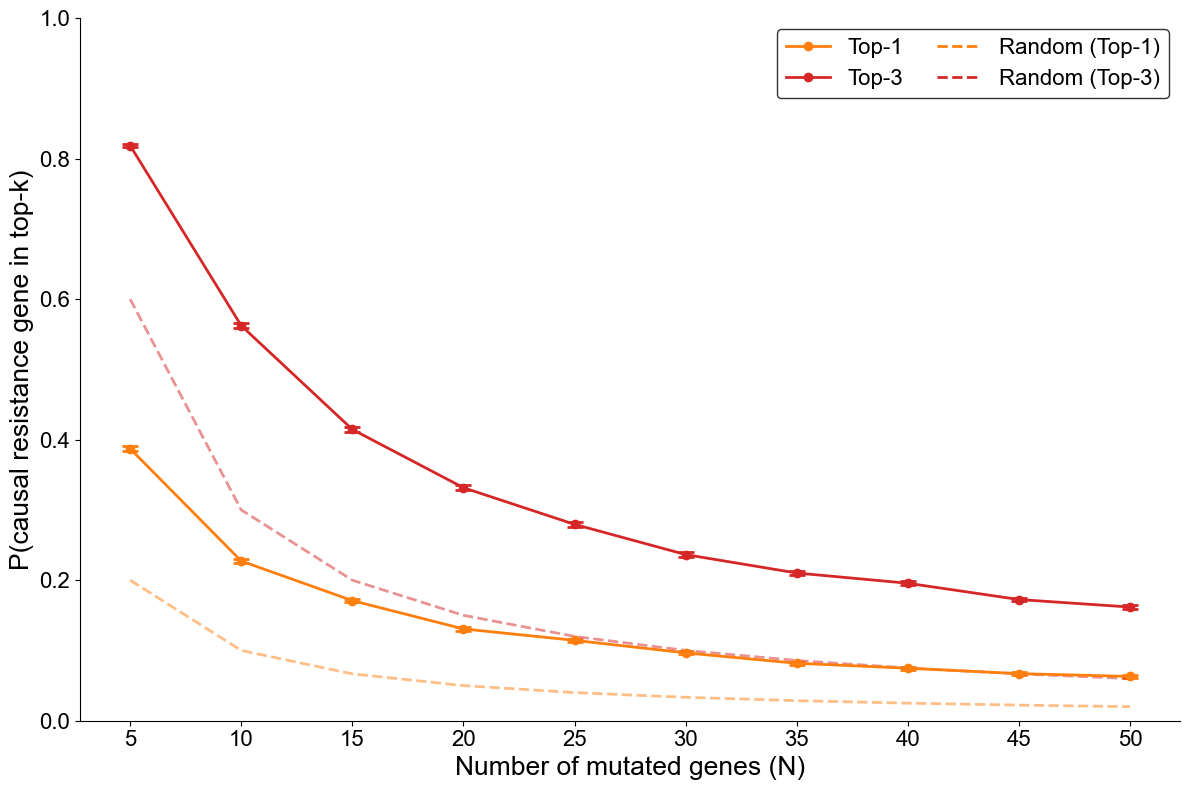

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = pd.read_csv("results/5_ML_graphs/knoll_dataset_model_predictions_score_causal.csv")

# === Font Setup ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})
# Load your actual data here
# df = pd.read_csv("your_predictions.csv")  # must have 'Score' and 'Label'

# Dummy data for testing (REMOVE if using real data)
np.random.seed(42)

def empirical_hitk_with_error(df, N_list, k_list=(1,3), trials=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {}
    errors = {}

    for N in N_list:
        for k in k_list:
            counts = []
            for _ in range(trials):
                s_causal = rng.choice(pos_scores)
                s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
                rank = 1 + np.sum(s_non > s_causal)
                counts.append(rank <= k)
            arr = np.array(counts)
            results[(N, k)] = arr.mean()
            errors[(N, k)] = arr.std(ddof=1) / np.sqrt(trials)
    return results, errors

# Run
N_list = [5,10,15,20,25,30,35,40,45,50]
hitk_results, hitk_errors = empirical_hitk_with_error(df, N_list=N_list, k_list=[1,3], trials=20000, rng=np.random.default_rng(42))

# === Plot ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# === Unified color per Top-k group ===
group_colors = {
    1: '#ff7f0e',  # orange
    3: '#d62728'   # red
}

plt.figure(figsize=(12, 8))

for k in [1, 3]:
    color = group_colors[k]

    # Model line
    y = [hitk_results[(N, k)] for N in N_list]
    yerr = [hitk_errors[(N, k)] for N in N_list]
    plt.errorbar(
        N_list, y, yerr=yerr,
        marker="o", label=f"Top-{k}",
        capsize=6, capthick=2, elinewidth=1.5,
        linewidth=2, color=color
    )

    # Random baseline line (same color, dashed)
    y_random = [k / N for N in N_list]
    plt.plot(
        N_list, y_random,
        linestyle="--", linewidth=2, color=color, alpha=0.5,
        label=f"Random (Top-{k})"
    )

# === Final plot styling ===
plt.ylim(0, 1)
plt.xlabel("Number of mutated genes (N)", fontsize=19)
plt.ylabel("P(causal resistance gene in top-k)", fontsize=19)
plt.xticks(N_list, fontsize=16)
plt.yticks(fontsize=16)

# Custom legend elements
legend_model = [
    Line2D([0], [0], color=group_colors[k], marker='o', linestyle='-', label=f"Top-{k}", linewidth=2)
    for k in [1, 3]
]
legend_random = [
    Line2D([0], [0], color=group_colors[k], linestyle='--', label=f"Random (Top-{k})", linewidth=2)
    for k in [1, 3]
]

# Combine and display in two-column layout
plt.legend(
    handles=legend_model + legend_random,
    loc='upper right',
    fontsize=16,
    frameon=True,
    edgecolor='black',
    ncol=2,
    columnspacing=1.5
)
plt.grid(False)

# Remove top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figure_6b_causal_mutation_analysis.jpeg", dpi=600)
plt.show()
